In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Country_Data = pd.read_csv('Country-data.csv')


NameError: name 'pd' is not defined

In [ ]:
Country_Data.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
Country_Data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


##Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Country_Data_sc = scaler.fit_transform(Country_Data.drop('country', axis=1))
Country_Data_sc


array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

##PCA (Dimensionality Reduction)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca_data = pca.fit_transform(Country_Data_sc)
pca

PCA()

In [ ]:
pca.explained_variance_ratio_

array([0.4595174 , 0.17181626, 0.13004259, 0.11053162, 0.07340211,
       0.02484235, 0.0126043 , 0.00981282, 0.00743056])

In [ ]:
pca = PCA(n_components=5)
pca_data = pca.fit_transform(Country_Data_sc)
pca_df = pd.DataFrame(pca_data)

##Find Optimal K Value

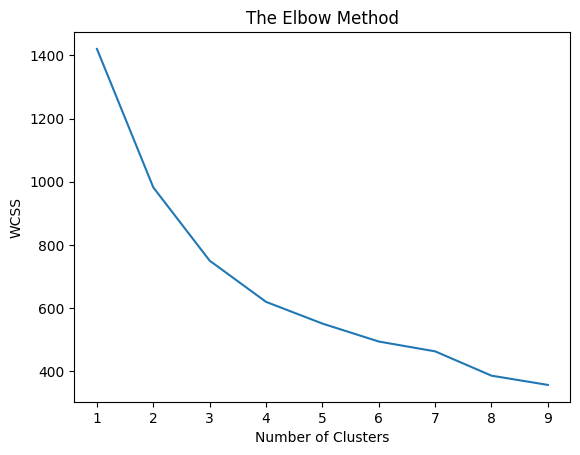

In [ ]:
from sklearn.cluster import KMeans

WCSS = []

for i in range(1,10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(pca_df)
  WCSS.append(kmeans.inertia_)

plt.plot(range(1,10), WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



#K Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
Country_Data['KM_Cluster'] = KMeans.fit_predict(kmeans, pca_df)
Country_Data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KM_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2


In [ ]:
Country_Data.groupby('KM_Cluster')[['gdpp','income','child_mort']].mean()

,gdpp,income,child_mort
KM_Cluster,,,
0,6461.767442,12321.744186,22.456977
1,42494.444444,45672.222222,5.000000
2,1766.711111,3539.844444,95.106667


##Clustering Classification
0-Developping,
1-Developed,
2-Underdeveloped(Need Aid)

In [ ]:
Country_Data['KM_Cluster'].value_counts().sort_values(ascending=False)

,count
KM_Cluster,
0,86
2,45
1,36


In [ ]:
Countries_need_aid_KMeans = Country_Data[Country_Data['KM_Cluster']==2].sort_values('child_mort',ascending=False)
Countries_need_aid_KMeans.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KM_Cluster
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662,2
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.20,55.0,5.20,399,2
32,Chad,150.0,36.8,4.53,43.5,1930,6.39,56.5,6.59,897,2
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.01,47.5,5.21,446,2
97,Mali,137.0,22.8,4.98,35.1,1870,4.37,59.5,6.55,708,2


##Visualizations

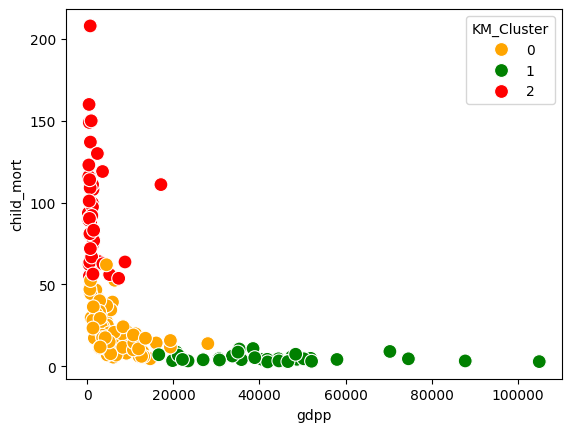

In [ ]:
#gdpp vs Child_mort

sns.scatterplot(x='gdpp', y='child_mort', hue='KM_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

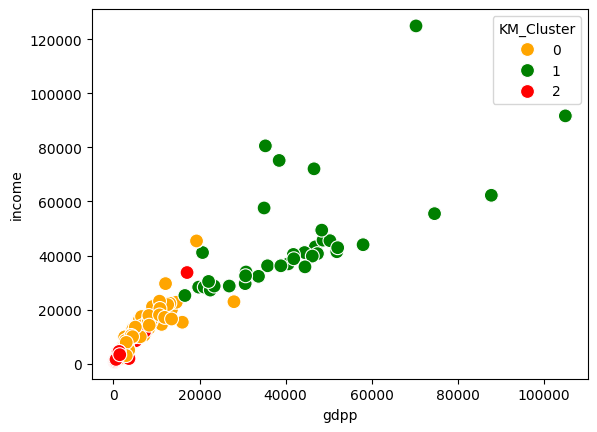

In [ ]:
#gdpp vs income

sns.scatterplot(x='gdpp', y='income', hue='KM_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

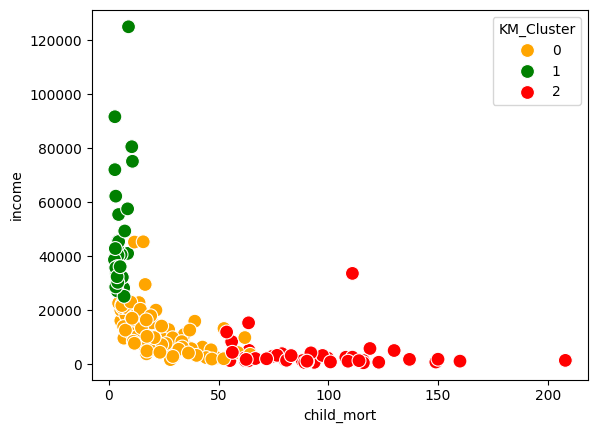

In [ ]:
#child_mort vs income

sns.scatterplot(x='child_mort', y='income', hue='KM_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

# Hierarchical Clustering

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

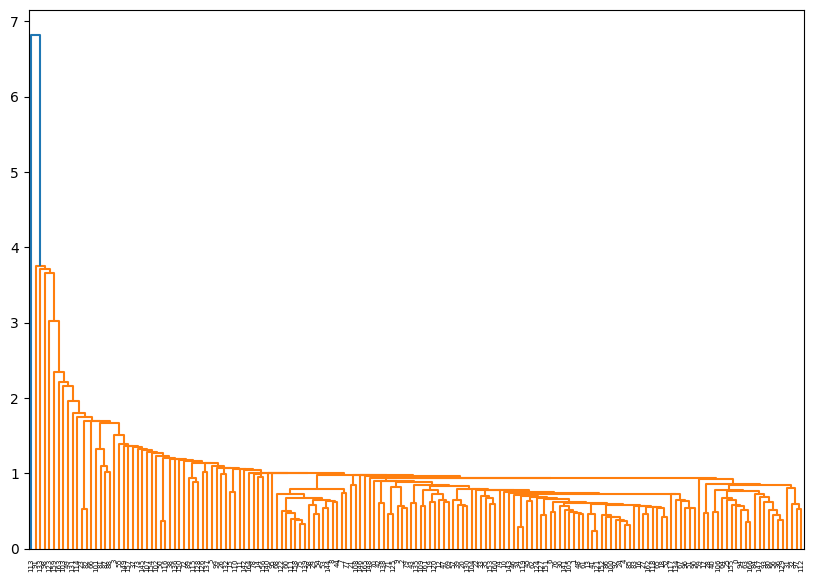

In [ ]:
linked = linkage(pca_df, method='single')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.show()

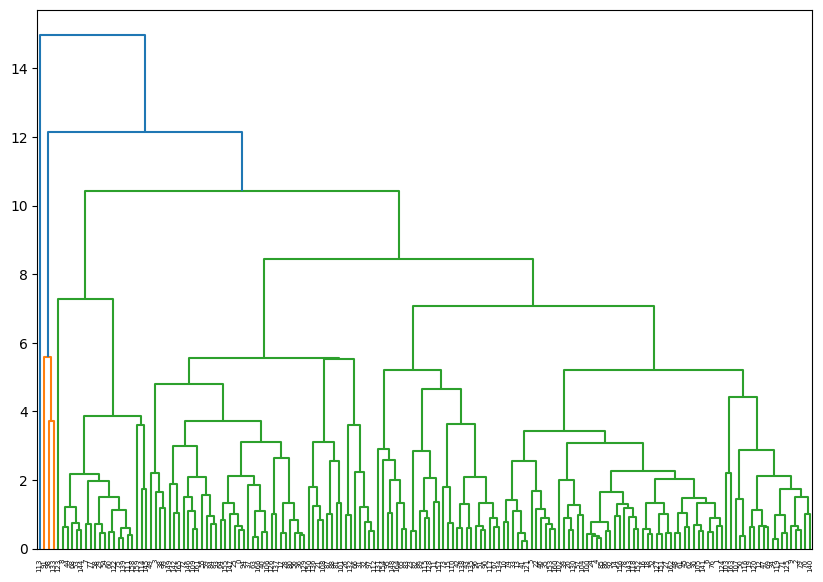

In [ ]:
linked = linkage(pca_df, method='complete')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.show()

From above dendogam decided the number of clusters as 4.

In [ ]:
Country_Data['H_Cluster'] = fcluster(linked, 3, criterion='maxclust')
Country_Data['H_Cluster']

,H_Cluster
0,2
1,2
2,2
3,2
4,2
...,...
162,2
163,2
164,2
165,2


In [ ]:
Country_Data.groupby('H_Cluster')[['gdpp','income','child_mort']].mean()

,gdpp,income,child_mort
H_Cluster,,,
1,57566.666667,64033.333333,4.133333
2,12208.490798,16355.294479,38.335583
3,2330.000000,5150.000000,130.000000


##Clustering Classification

1 - Developed Countries
2 - Developing Countries
3 - Underdeveloped Countries(need aid)

In [ ]:
Countries_need_aid_H_cluster = Country_Data[Country_Data['H_Cluster']==3].sort_values('child_mort',ascending=False)
Countries_need_aid_H_cluster

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KM_Cluster,H_Cluster
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.0,60.5,5.84,2330,2,3


In [ ]:
Country_Data['H_Cluster'].value_counts().sort_values(ascending=False)

,count
H_Cluster,
2,163
1,3
3,1


##Visualizations

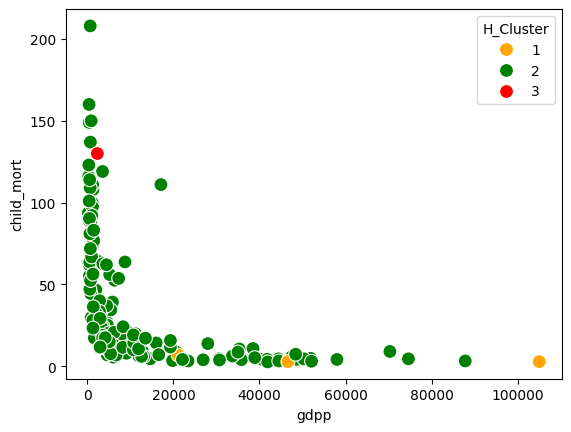

In [ ]:
#gdpp vs Child_mort

sns.scatterplot(x='gdpp', y='child_mort', hue='H_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

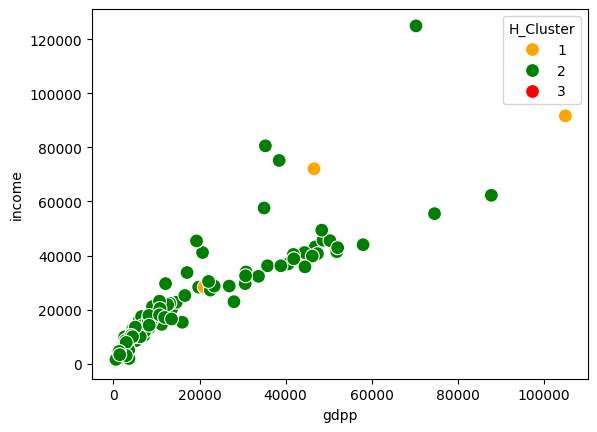

In [ ]:
#gdpp vs income

sns.scatterplot(x='gdpp', y='income', hue='H_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

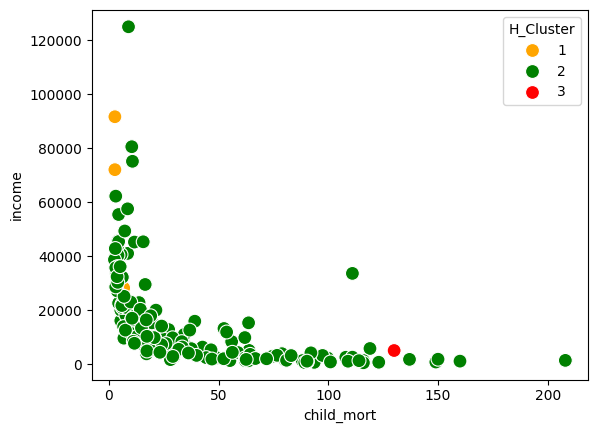

In [ ]:
#child_mort vs income

sns.scatterplot(x='child_mort', y='income', hue='H_Cluster', palette = ['orange','green','red'], s=100, data=Country_Data)
plt.show()

In [ ]:
Country_Data['Development'] = Country_Data['KM_Cluster'].map({1: 'Developed',0: 'Developing', 2: 'Underdeveloped'})


In [ ]:
final_countries = Country_Data[Country_Data['KM_Cluster'] == 2].sort_values(by=['child_mort','gdpp'], ascending=[False, True])

final_countries[['country','gdpp','income','child_mort']].head(5)



,country,gdpp,income,child_mort
66,Haiti,662,1500,208.0
132,Sierra Leone,399,1220,160.0
32,Chad,897,1930,150.0
31,Central African Republic,446,888,149.0
97,Mali,708,1870,137.0


In [ ]:
final_countries.to_excel("Final_Countries_Needing_Aid.xlsx", index=False)